# This example replicates all the results for the 2D experiments in the paper titled "Generalizable motion planning via operator learning"

### This notebook relies on a series of datasets available on Hugging Face (See README of repo). Please download them and place them in the dataset directory relative to this path.  ##

Please feel free to email lbhan@ucsd.edu if you have any issues or make a github issue!

In [1]:
# Preliminary packages
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from timeit import default_timer
from functools import reduce
from pathlib import Path
import operator
import math
from time import time
from prettytable import PrettyTable
from scipy.ndimage import distance_transform_edt

from utilities.losses import LpLoss
from utilities.normalizers import GaussianNormalizer
from utilities.plotting import set_size

if torch.cuda.is_available():
    torch.set_default_device('cuda')
    device = 'cuda'
    print("Using CUDA as the default device.")
elif torch.backends.mps.is_available():
    torch.set_default_device('mps')
    device = 'mps'
    print("Using MPS as the default device.")
else:
    device = 'cpu'
    print("Using CPU as the default device.")

# SETUP PLOTTING FORMATTING
tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "times",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/bel fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(tex_fonts)

from models.fnoMultiGoal import FNO2dMultiGoal
from models.dafnoMultiGoal import DAFNO2dMultiGoal
from models.deepnormMultiGoal import DEEPNORM2dMultiGoal

# Needed for approximating the SDF solution
from models.fno import FNO2d

def clear_device_cache(dvc):
    if dvc == "cuda":
        torch.cuda.empty_cache()
    elif dvc == "mps":
        torch.mps.empty_cache()

clear_device_cache(device)

Using MPS as the default device.


In [2]:
# Load different set of models for training
savepaths = ["FNOMultiGoal", "DAFNOMultiGoal", "DeepnormMultiGoal", "DeepnormMultiGoal"]

model_classes = [FNO2dMultiGoal(4,1, 8,8,16),\
                 DAFNO2dMultiGoal(4, 8,8, 16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16)]

# controls whether or not the mask function in DAFNO is applied
mask_func_arr = [lambda a: 1, lambda a: a, lambda a: a,  lambda a: a]

In [3]:
# Load and build normalized torch datasets
dirPath = 'dataset/synthetic/64x64/'
mask = np.load(dirPath + 'mask.npy')
mask = torch.tensor(mask, dtype=torch.float).to(device)
dist_in = np.load(dirPath + 'dist_in.npy')
dist_in = torch.tensor(dist_in, dtype=torch.float).to(device)
goals = np.load(dirPath + 'goal.npy')
goals = torch.tensor(goals, dtype=torch.int).to(device)
def smooth_chi(mask, dist, smooth_coef):
    return torch.mul(torch.tanh(dist * smooth_coef), (mask - 0.5)) + 0.5
input = smooth_chi(mask, dist_in, 5)
output = np.load(dirPath + 'output.npy')
output = torch.tensor(output, dtype=torch.float).to(device)

nData = len(input)
nTrain = int(nData * 0.8)
nTest = int(nData*0.2)
batch_size=20
mask_train = mask[:nTrain]
mask_test = mask[-nTest:]
goals_train = goals[:nTrain]
goals_test = goals[-nTest:]
chi_train = input[:nTrain]
chi_test = input[-nTest:]
y_train = output[:nTrain]
y_test = output[-nTest:]
print(nTest, nTrain)
mask_train = mask_train.reshape(nTrain, input.shape[1], input.shape[2], 1)
mask_test = mask_test.reshape(nTest, input.shape[1], input.shape[2], 1)
goals_train = goals_train.reshape(nTrain, 2)
goals_test = goals_test.reshape(nTest, 2)
chi_train = chi_train.reshape(nTrain, input.shape[1], input.shape[2], 1)
chi_test = chi_test.reshape(nTest, input.shape[1], input.shape[2], 1)

y_train = y_train.reshape(nTrain, input.shape[1], input.shape[2], 1)
y_test = y_test.reshape(nTest, input.shape[1], input.shape[2], 1)
        
trainData = DataLoader(TensorDataset(mask_train, chi_train, goals_train, y_train), batch_size=batch_size, shuffle=False, generator=torch.Generator(device=device))
testData = DataLoader(TensorDataset(mask_test, chi_test, goals_test, y_test), batch_size=batch_size, shuffle=False, generator=torch.Generator(device=device))
trainDataSDF = DataLoader(TensorDataset(mask_train, dist_in[:nTrain]), batch_size=batch_size, shuffle=True,  generator=torch.Generator(device=device))
testDataSDF = DataLoader(TensorDataset(mask_test, dist_in[-nTest:]), batch_size=batch_size, shuffle=True,  generator=torch.Generator(device=device))

200 800


# 1. Training the neural operators for approximating the Eikonal Solution for the Value Function
### Note, this is not necessary if one downloads the models as instructed in the README and prefers to use pretrained models

In [4]:
def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul,
                    list(p.size()+(2,) if p.is_complex() else p.size()))
    return c

# Train value function model
def train_model(lr, gamma, wd, batch_size, epochs, scheduler_step, mask_func,loss_type, normalizer,\
                model, trainData, testData, print_output, save_file, file_path):
    # Setup optimizers
    loss_func = LpLoss(d=2, p=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=gamma)

    # Setup data collection
    training_losses = []
    test_losses = []
    train_time_arr = []
    best_model_weights = None
    best_training_loss = np.inf
    best_test_loss = np.inf
    best_epoch = None

    # Print header
    print("Training model", file_path)
    print("Epoch", "Epoch time", "Train loss", "Test loss")

    for ep in range(epochs):
        model.train()

        # Training
        t1 = default_timer()
        train_loss = 0
        samples_train = 0
        for mask, chi, goals, y in trainData:
            mask.to(device), chi.to(device), y.to(device)
            # Setup training
            optimizer.zero_grad()

            # Forward pass
            out = model(chi, goals)
            if normalizer is not None:
                out = normalizer.decode(out) * mask_func(mask)
                y = normalizer.decode(y) * mask_func(mask)
            else:
                out = out*mask_func(mask)
            # PINN loss
            if loss_type == "PINN":
                grad_out = torch.linalg.vector_norm(torch.stack(list(torch.gradient(out.reshape(out.shape[0], out.shape[1], out.shape[2]), dim=[1, 2])), dim=0), dim=0)
                grad_y = torch.linalg.vector_norm(torch.stack(list(torch.gradient(y.reshape(out.shape[0], out.shape[1], out.shape[2]), dim=[1, 2])), dim=0), dim=0)
                # set boundary gradients to zero
                grad_mask = grad_y.clone()
                grad_mask[grad_mask >= 1.01] = 0
               
                loss =loss_func(out.view(y.shape[0], y.shape[1], y.shape[2]), y.view(y.shape[0], y.shape[1], y.shape[2])) + \
                0.05*loss_func((grad_out*grad_mask).view(batch_size, y.shape[1], y.shape[2]),grad_mask.view((batch_size, y.shape[1], y.shape[2])))
            else:
                loss =loss_func(out.view(y.shape[0], y.shape[1], y.shape[2]), y.view(y.shape[0], y.shape[1], y.shape[2])) 
            train_loss += loss.item()
            samples_train += y.shape[0]

            # Backprop
            loss.backward()
            optimizer.step()       
        scheduler.step()
        model.eval()
        test_loss = 0
        loss = 0
        t2 = default_timer()
        # Testing
        samples_test = 0
        with torch.no_grad():
            for mask, chi, goals, y in testData:
                out = model(chi, goals)
                if normalizer is not None:
                    out = normalizer.decode(out) * mask_func(mask)
                else:
                    out = out*mask_func(mask)
                # PINN loss
                if loss_type == "PINN":
                    grad_out = torch.linalg.vector_norm(torch.stack(list(torch.gradient(out.reshape(out.shape[0], out.shape[1], out.shape[2]), dim=[1, 2])), dim=0), dim=0)
                    grad_y = torch.linalg.vector_norm(torch.stack(list(torch.gradient(y.reshape(out.shape[0], out.shape[1], out.shape[2]), dim=[1, 2])), dim=0), dim=0)
                    # set boundary gradients to zero
                    grad_mask = grad_y.clone()
                    grad_mask[grad_mask >= 1.01] = 0
                   
                    loss =loss_func(out.view(y.shape[0], y.shape[1], y.shape[2]), y.view(y.shape[0], y.shape[1], y.shape[2])) + \
                    0.05*loss_func((grad_out*grad_mask).view(batch_size, y.shape[1], y.shape[2]),grad_mask.view((batch_size, y.shape[1], y.shape[2])))
                else:
                    loss =loss_func(out.view(y.shape[0], y.shape[1], y.shape[2]), y.view(y.shape[0], y.shape[1], y.shape[2])) 
                test_loss += loss.item()
                samples_test += y.shape[0]
        # Collect data and setup best model
        train_loss /= samples_train
        test_loss /= samples_test
        training_losses.append(train_loss)
        test_losses.append(test_loss)
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_training_loss = train_loss
            best_epoch = ep   
            best_model_weights = model.state_dict()

        t2 = default_timer()
        train_time_arr.append(t2-t1)
        if ep%10 == 0 and print_output:
            print(ep, t2-t1, train_loss, test_loss)

    if save_file:
        Path(file_path).mkdir(parents=True, exist_ok=True)
        np.savetxt(file_path + "/training_losses.txt", training_losses)
        np.savetxt(file_path + "/test_losses.txt", test_losses)
        np.savetxt(file_path + "/training_times.txt", train_time_arr)
        torch.save(best_model_weights, file_path + "/best_model.pt")
        f = open(file_path + "/aggregate_results.txt", "w")
        f.write("ModelParameters: " + str(count_params(model)) + "\n")
        f.write("BestL2TrainingError: " + str(best_training_loss) + "\n")
        f.write("BestL2TestingError: " + str(best_test_loss) + "\n")
        f.write("BestEpoch: " + str(best_epoch) + "\n")
        f.write("TotalTrainingTime: " + str(np.sum(train_time_arr)) + "\n")
        f.close()

def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul,
                    list(p.size()+(2,) if p.is_complex() else p.size()))
    return c

# Train SDF function model
def train_model_SDF(lr, gamma, wd, batch_size, epochs, scheduler_step, \
                model, trainData, testData, print_output, save_file, file_path):
    # Setup optimizers
    loss_func = LpLoss(d=2, p=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=gamma)

    # Setup data collection
    training_losses = []
    test_losses = []
    train_time_arr = []
    best_model_weights = None
    best_training_loss = np.inf
    best_test_loss = np.inf
    best_epoch = None

    # Print header
    print("Training model", file_path)
    print("Epoch", "Epoch time", "Train loss", "Test loss")

    for ep in range(epochs):
        model.train()

        # Training
        t1 = default_timer()
        train_loss = 0
        samples_train = 0
        for mask, y in testData:
            mask.to(device), y.to(device)
            # Setup training
            optimizer.zero_grad()
    
            # Forward pass
            out = model(mask)

            loss =loss_func(out.view(y.shape[0], y.shape[1], y.shape[2]), y.view(y.shape[0], y.shape[1], y.shape[2])) 
            train_loss += loss.item()
            samples_train += y.shape[0]

            # Backprop
            loss.backward()
            optimizer.step()       
        scheduler.step()
        model.eval()
        test_loss = 0
        loss = 0
        t2 = default_timer()
        # Testing
        samples_test = 0
        with torch.no_grad():
            for mask, y in testData:
                mask.to(device), y.to(device)
                # Setup training
                optimizer.zero_grad()
    
                # Forward pass
                out = model(mask)
                
                loss =loss_func(out.view(y.shape[0], y.shape[1], y.shape[2]), y.view(y.shape[0], y.shape[1], y.shape[2])) 
                test_loss += loss.item()
                samples_test += y.shape[0]
        # Collect data and setup best model
        train_loss /= samples_train
        test_loss /= samples_test
        training_losses.append(train_loss)
        test_losses.append(test_loss)
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_training_loss = train_loss
            best_epoch = ep   
            best_model_weights = model.state_dict()

        t2 = default_timer()
        train_time_arr.append(t2-t1)
        if ep%10 == 0 and print_output:
            print(ep, t2-t1, train_loss, test_loss)

    if save_file:
        Path(file_path).mkdir(parents=True, exist_ok=True)
        np.savetxt(file_path + "/training_losses.txt", training_losses)
        np.savetxt(file_path + "/test_losses.txt", test_losses)
        np.savetxt(file_path + "/training_times.txt", train_time_arr)
        torch.save(best_model_weights, file_path + "/best_model.pt")
        f = open(file_path + "/aggregate_results.txt", "w")
        f.write("ModelParameters: " + str(count_params(model)) + "\n")
        f.write("BestL2TrainingError: " + str(best_training_loss) + "\n")
        f.write("BestL2TestingError: " + str(best_test_loss) + "\n")
        f.write("BestEpoch: " + str(best_epoch) + "\n")
        f.write("TotalTrainingTime: " + str(np.sum(train_time_arr)) + "\n")
        f.close()

In [5]:
# Trains the 4 different models. The ordering is FNO, DAFNO, PNO w reg loss, and PNO w PINN loss. 
# Load different set of models for training
savepaths = ["FNOMultiGoal", "DAFNOMultiGoal", "DeepnormMultiGoal", "DeepnormMultiGoal"]

model_classes = [FNO2dMultiGoal(4,1, 8,8,16),\
                 DAFNO2dMultiGoal(4, 8,8, 16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16)]

# controls whether or not the mask function in DAFNO is applied
mask_func_arr = [lambda a: 1, lambda a: a, lambda a: a,  lambda a: a]
loss_type_arr = ["L2", "L2", "L2", "PINN"]
model_save_paths = ["FNO", "DAFNO", "PNO", "PNOwPINN"]

for i in range(3, len(savepaths)):
        train_model(lr=1e-3, gamma=0.5, wd=1e-5, batch_size=20, epochs=500, scheduler_step=50, model=model_classes[i],\
                    mask_func=mask_func_arr[i], loss_type=loss_type_arr[i], normalizer=None,\
                    trainData=trainData, testData=testData,\
                    print_output=True, save_file=True, file_path="./results/" + model_save_paths[i])

Training model ./results/PNOwPINN
Epoch Epoch time Train loss Test loss


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 64, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 64, 64]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reus

0 18.20319583400851 1.0467841410636902 1.031511402130127
10 14.9480861670163 0.7499500119686127 0.7010722494125367
20 14.658427834016038 0.7250677406787872 0.643900146484375
30 14.791803459025687 0.6536475276947021 0.588136863708496
40 15.2857470420131 0.6262947857379914 0.5634417629241943
50 14.822693416004768 0.5930024528503418 0.5305094051361084
60 14.50014208300854 0.5889599871635437 0.5306494474411011
70 14.65572270800476 0.5798041546344757 0.5215216827392578
80 14.46304545897874 0.5653562879562378 0.5083519172668457
90 14.580313749989728 0.5483189558982849 0.48923469066619873
100 14.97027491699555 0.5320235157012939 0.46813819885253904
110 14.880419790977612 0.5123120367527008 0.45288217544555665
120 14.759873958013486 0.4987765395641327 0.4405125427246094
130 14.703873999998905 0.4969548058509827 0.4369539451599121
140 14.629234749998432 0.49959270358085633 0.4378395414352417
150 14.750313541007927 0.5031091165542603 0.44148274421691897
160 14.4092016670038 0.5008323550224304 0.

# 2. Training the FNO for approximating the Eikonal Solution for the SDF function
### Note, this is not necessary if one downloads the FNO SDF model as instructed in the README and prefers to use pretrained models

In [6]:
# Train a FNO to learn the signed distance function smoothed. 
savepathsSDF = ["FNOSDF"]
model_classes_SDF = [FNO2d(4,1, 8, 8, 16)]

In [7]:
for i in range(len(savepathsSDF)):
    train_model_SDF(lr=1e-3, gamma=0.5, wd=3e-6, batch_size=20, epochs=500, scheduler_step=50, model=model_classes_SDF[i],\
                    trainData=trainDataSDF, testData=testDataSDF,\
                    print_output=True, save_file=True, file_path="./results/" + savepathsSDF[i])

Training model ./results/FNOSDF
Epoch Epoch time Train loss Test loss


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 65, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 65, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reus

0 3.4177198329998646 0.9724632835388184 0.9482675266265869
10 0.4734740830026567 0.7093760013580322 0.7083411502838135
20 1.048433166986797 0.6586590242385865 0.6657734203338623
30 0.4269492920138873 0.686230297088623 0.6841053009033203
40 0.5168209999974351 0.6937440824508667 0.732878851890564
50 0.6877645839995239 0.6881800270080567 0.6887583923339844
60 0.6212315420270897 0.6881278467178344 0.6899686479568481
70 0.6540832089958712 0.6948144912719727 0.6949851894378662
80 0.44980599998962134 0.6900390625 0.6876392889022828
90 0.49667000002227724 0.7203249883651733 0.6867017126083375
100 0.47661900002276525 0.6847744083404541 0.6835064315795898
110 0.522211540985154 0.6913004112243653 0.6849100637435913
120 0.4369252090109512 0.6896956539154053 0.6896998310089111
130 0.48192037499393336 0.6863072061538696 0.6839975309371948
140 0.33300591702573 0.7015146112442017 0.6938449192047119
150 0.3308035829977598 0.6810639905929565 0.6791227197647095
160 0.33449308297713287 0.6789040184020996 

# 3. Quantitatively evaluating the models

Please place all the model files in the results folder. If you trained them yourselves, this is automatically done. Otherwise, follow
the instructions on the README.md

In [9]:
# Load all the models
model_classes = [FNO2dMultiGoal(4,1, 8,8,16),\
                 DAFNO2dMultiGoal(4, 8,8, 16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16)]

model_classes_SDF = [FNO2d(4,1, 8, 8, 16)]

model_save_paths = ["FNO", "DAFNO", "PNO", "PNOwPINN"]
savepathsSDF = ["FNOSDF"]

mask_func_arr = [lambda a: 1, lambda a: a, lambda a: a,  lambda a: a]

modelFNO = model_classes[0]
modelFNO.load_state_dict(torch.load("./results/" + model_save_paths[0] + "/best_model.pt", weights_only=True, map_location=device))
modelDAFNO = model_classes[1]
modelDAFNO.load_state_dict(torch.load("./results/" + model_save_paths[1] + "/best_model.pt", weights_only=True, map_location=device))
modelPNO = model_classes[2]
modelPNO.load_state_dict(torch.load("./results/" + model_save_paths[2] + "/best_model.pt", weights_only=True, map_location=device))
modelPNOwPINN = model_classes[3]
modelPNOwPINN.load_state_dict(torch.load("./results/" + model_save_paths[3] + "/best_model.pt", weights_only=True, map_location=device))

modelSDF = model_classes_SDF[0]
modelSDF.load_state_dict(torch.load("./results/"+savepathsSDF[0]+"/best_model.pt", weights_only=True, map_location=device))

modelFNO.eval()
modelDAFNO.eval()
modelPNO.eval()
modelPNOwPINN.eval()
modelSDF.eval()

FNO2d(
  (fc0): Linear(in_features=1, out_features=16, bias=True)
  (fc1): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (conv0): SpectralConv2d()
  (w0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv1): SpectralConv2d()
  (w1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): SpectralConv2d()
  (w2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv3): SpectralConv2d()
  (w3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
)

In [10]:
# Testing function for the models. USES L2 loss
def test_model(model, mask_func, data, model_name, sdfModel=None, numTimeInst=1000, print_output=True):
    loss_func = LpLoss(d=2, p=2)
    test_loss = 0
    samples_test = 0
    # Testing
    with torch.no_grad():
        for mask, chi, goals, y in data:
            if sdfModel is not None:
                chi = smooth_chi(mask, sdfModel(mask), 5)
            out = model(chi, goals)
            out = out*mask_func(mask)
            test_loss += loss_func(out.view(y.shape[0], y.shape[1], y.shape[2]), y.view(y.shape[0], y.shape[1], y.shape[2])).item()
            samples_test += y.shape[0]
        test_loss /= samples_test
    with torch.no_grad():
        timeSDF = 0
        timeVF = 0
        inp = mask[0].detach().cpu().numpy()
        for i in range(numTimeInst):
            # compute SDF
            if sdfModel is not None:
                t1 = default_timer()
                chi = smooth_chi(mask[0], sdfModel(mask[0].reshape(1, mask.shape[1], mask.shape[1], 1)), 5)
                t2 = default_timer()
            else:
                t1 = default_timer()
                distance_transform_edt(inp.reshape(mask.shape[1], mask.shape[1]))
                t2 = default_timer()
            chiInp = chi[0].reshape(1, chi.shape[1], chi.shape[2], chi.shape[3]).to(device)
            goalInp = goals[0].reshape(1, 2).to(device)
            maskInp = mask[0].reshape(1, mask.shape[1], mask.shape[2], mask.shape[3]).to(device)
            t3 = default_timer()
            out = model(chiInp, goalInp)
            out = out*mask_func(maskInp)
            t4 = default_timer()
            timeSDF += (t2-t1)
            timeVF += (t4-t3)
        timeVF /= numTimeInst
        timeSDF /= numTimeInst
    time = 0
    # Multiply by 1k to convert to milliseconds
    if print_output:
        print("Model Name: " + model_name + " - Testing Average L2 Relative Loss:", test_loss, "Avg Compute time(ms) (SDF, VF, total):", timeSDF*1000, 1000*timeVF, timeSDF*1000+1000*timeVF)
    return test_loss,timeSDF*1000, 1000*timeVF, timeSDF*1000+1000*timeVF

# data smoother. Smooth_coeff= 0.5
def smooth_chi(mask, dist, smooth_coef):
    return torch.mul(torch.tanh(dist * smooth_coef), (mask - 0.5)) + 0.5
# dataset loader
# trainDataCount,testDataCount control train/test ratio. All sizes larger then 64x64 are testing data only. 
def load_dataset(filepath, trainDataCount, testDataCount, batch_size=2):
    dirPath = './dataset/' + filepath +"/"
    mask = np.load(dirPath + 'mask.npy')
    mask = torch.tensor(mask, dtype=torch.float).to(device)
    dist_in = np.load(dirPath + 'dist_in.npy')
    dist_in = torch.tensor(dist_in, dtype=torch.float).to(device)
    goals = np.load(dirPath + 'goal.npy')
    goals = torch.tensor(goals, dtype=torch.int).to(device)
    input = smooth_chi(mask, dist_in, 5)
    output = np.load(dirPath + 'output.npy')
    output = torch.tensor(output, dtype=torch.float).to(device)
    
    nData = len(input)
    nTrain = int(nData * trainDataCount)
    nTest = int(nData*testDataCount)
    mask_train = mask[:nTrain]
    mask_test = mask[-nTest:]
    goals_train = goals[:nTrain]
    goals_test = goals[-nTest:]
    chi_train = input[:nTrain]
    chi_test = input[-nTest:]
    y_train = output[:nTrain]
    y_test = output[-nTest:]
    mask_train = mask_train.reshape(nTrain, input.shape[1], input.shape[2], 1)
    mask_test = mask_test.reshape(nTest, input.shape[1], input.shape[2], 1)
    goals_train = goals_train.reshape(nTrain, 2)
    goals_test = goals_test.reshape(nTest, 2)
    chi_train = chi_train.reshape(nTrain, input.shape[1], input.shape[2], 1)
    chi_test = chi_test.reshape(nTest, input.shape[1], input.shape[2], 1)
    
    y_train = y_train.reshape(nTrain, input.shape[1], input.shape[2], 1)
    y_test = y_test.reshape(nTest, input.shape[1], input.shape[2], 1)
            
    trainData = DataLoader(TensorDataset(mask_train, chi_train, goals_train, y_train), batch_size=batch_size, shuffle=False, generator=torch.Generator(device=device))
    testData = DataLoader(TensorDataset(mask_test, chi_test, goals_test, y_test), batch_size=batch_size, shuffle=False, generator=torch.Generator(device=device))
    print("Load dataset complete(train size, test size)", nTrain, nTest)
    return trainData, testData

In [11]:
# Warning this will take some time if numTimeInst = 1000 like in the paper. Recommendation is to start with 100. 
# Requires significant memory as well. Broken into blocks as 1024 can be expensive to compute. 
numTimeInst = 100
# BATCHSIZE = 2 for all except 64x64. This is due to limited GPU memory. If you have more mememory, increase batch_size here
batch_size=2

In [12]:

# 64x64 synthetic dataset
trainData64, testData64 = load_dataset("synthetic/64x64", trainDataCount=0.8, testDataCount=0.2, batch_size=20)
fnoTestError64, fnoSDFTime64, fnoVTime64, fnoTotalTime64 = test_model(modelFNO, mask_func_arr[0],testData64, "FNO", numTimeInst=numTimeInst)
dafnoTestError64, dafnoSDFTime64, dafnoVTime64, dafnoTotalTime64 = test_model(modelDAFNO, mask_func_arr[1],testData64, "DAFNO", numTimeInst=numTimeInst)
pnoTestError64, pnoSDFTime64, pnoVTime64, pnoTotalTime64 = test_model(modelPNO, mask_func_arr[2],testData64, "PNO", sdfModel = modelSDF,numTimeInst=numTimeInst)
pnoWPINNTestError64, pnoWPINNSDFTime64, pnoWPINNVTime64, pnoWPINNTotalTime64 = test_model(modelPNOwPINN, mask_func_arr[3],testData64, "PNO w PINN", sdfModel = modelSDF, numTimeInst=numTimeInst)

Load dataset complete(train size, test size) 800 200


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 16, 65, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 16, 65, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse 

Model Name: FNO - Testing Average L2 Relative Loss: 0.18501486539840697 Avg Compute time(ms) (SDF, VF, total): 0.328369970084168 19.91097382910084 20.239343799185008


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 16, 64, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 16, 64, 64]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse 

Model Name: DAFNO - Testing Average L2 Relative Loss: 0.12763908982276917 Avg Compute time(ms) (SDF, VF, total): 0.30695340217789635 13.329482108529191 13.636435510707088
Model Name: PNO - Testing Average L2 Relative Loss: 0.2987779974937439 Avg Compute time(ms) (SDF, VF, total): 4.6493592104525305 18.12556122924434 22.77492043969687
Model Name: PNO w PINN - Testing Average L2 Relative Loss: 0.4695443105697632 Avg Compute time(ms) (SDF, VF, total): 2.477699181472417 12.340767048299313 14.81846622977173


In [13]:
# 256x256 synthetic dataset
trainData256, testData256 = load_dataset("synthetic/256x256", trainDataCount=0, testDataCount=1, batch_size=batch_size)
fnoTestError256, fnoSDFTime256, fnoVTime256, fnoTotalTime256 = test_model(modelFNO, mask_func_arr[0],testData256, "FNO", numTimeInst=numTimeInst)
dafnoTestError256, dafnoSDFTime256, dafnoVTime256, dafnoTotalTime256 = test_model(modelDAFNO, mask_func_arr[1],testData256, "DAFNO", numTimeInst=numTimeInst)
pnoTestError256, pnoSDFTime256, pnoVTime256, pnoTotalTime256 = test_model(modelPNO, mask_func_arr[2],testData256, "PNO", sdfModel = modelSDF, numTimeInst=numTimeInst)
pnoWPINNTestError256, pnoWPINNSDFTime256, pnoWPINNVTime256, pnoWPINNTotalTime256 = test_model(modelPNOwPINN, mask_func_arr[3],testData256, "PNO w PINN", sdfModel = modelSDF, numTimeInst=numTimeInst)

del trainData256, testData256
with torch.no_grad():
    clear_device_cache(device)

Load dataset complete(train size, test size) 0 100


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 257, 129]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 257, 257]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly re

Model Name: FNO - Testing Average L2 Relative Loss: 0.790535774230957 Avg Compute time(ms) (SDF, VF, total): 3.701242101378739 29.073022489028517 32.774264590407256


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 256, 129]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 256, 256]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly re

Model Name: DAFNO - Testing Average L2 Relative Loss: 0.410171617269516 Avg Compute time(ms) (SDF, VF, total): 2.950251199945342 13.630018708354328 16.58026990829967
Model Name: PNO - Testing Average L2 Relative Loss: 0.2892907494306564 Avg Compute time(ms) (SDF, VF, total): 4.311841738817748 48.74458499980392 53.05642673862167
Model Name: PNO w PINN - Testing Average L2 Relative Loss: 0.4594652515649795 Avg Compute time(ms) (SDF, VF, total): 4.165779169125017 47.332476190058514 51.49825535918353


In [14]:
# 512x512 synthetic dataset
trainData512, testData512 = load_dataset("synthetic/512x512", trainDataCount=0, testDataCount=1, batch_size=batch_size)
fnoTestError512, fnoSDFTime512, fnoVTime512, fnoTotalTime512 = test_model(modelFNO, mask_func_arr[0],testData512, "FNO", numTimeInst=numTimeInst)
dafnoTestError512, dafnoSDFTime512, dafnoVTime512, dafnoTotalTime512 = test_model(modelDAFNO, mask_func_arr[1],testData512, "DAFNO", numTimeInst=numTimeInst)
pnoTestError512, pnoSDFTime512, pnoVTime512, pnoTotalTime512 = test_model(modelPNO, mask_func_arr[2],testData512, "PNO", sdfModel = modelSDF, numTimeInst=numTimeInst)
pnoWPINNTestError512, pnoWPINNSDFTime512, pnoWPINNVTime512, pnoWPINNTotalTime512 = test_model(modelPNOwPINN, mask_func_arr[3],testData512, "PNO w PINN", sdfModel = modelSDF, numTimeInst=numTimeInst)

del trainData512, testData512
with torch.no_grad():
    clear_device_cache(device)

Load dataset complete(train size, test size) 0 100


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 513, 257]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 513, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly re

Model Name: FNO - Testing Average L2 Relative Loss: 0.8520141136646271 Avg Compute time(ms) (SDF, VF, total): 16.321344251045957 73.13906844239682 89.46041269344278


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 512, 257]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 512, 512]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly re

Model Name: DAFNO - Testing Average L2 Relative Loss: 0.430396346449852 Avg Compute time(ms) (SDF, VF, total): 17.526982131239492 24.39367004088126 41.920652172120754
Model Name: PNO - Testing Average L2 Relative Loss: 0.28792533665895464 Avg Compute time(ms) (SDF, VF, total): 3.8054833287606016 177.86614418786485 181.67162751662545
Model Name: PNO w PINN - Testing Average L2 Relative Loss: 0.4588380032777786 Avg Compute time(ms) (SDF, VF, total): 3.6467625203658827 178.28722038771957 181.93398290808545


In [15]:
# 1024x1024 synthetic dataset
trainData1024, testData1024 = load_dataset("synthetic/1024x1024", trainDataCount=0, testDataCount=1, batch_size=batch_size)
fnoTestError1024, fnoSDFTime1024, fnoVTime1024, fnoTotalTime1024 = test_model(modelFNO, mask_func_arr[0],testData1024, "FNO", numTimeInst=numTimeInst)
dafnoTestError1024, dafnoSDFTime1024, dafnoVTime1024, dafnoTotalTime1024 = test_model(modelDAFNO, mask_func_arr[1],testData1024, "DAFNO", numTimeInst=numTimeInst)
pnoTestError1024, pnoSDFTime1024, pnoVTime1024, pnoTotalTime1024 = test_model(modelPNO, mask_func_arr[2],testData1024, "PNO",sdfModel = modelSDF,  numTimeInst=numTimeInst)
pnoWPINNTestError1024, pnoWPINNSDFTime1024, pnoWPINNVTime1024, pnoWPINNTotalTime1024 = test_model(modelPNOwPINN, mask_func_arr[3],testData1024, "PNO w PINN",sdfModel = modelSDF,  numTimeInst=numTimeInst)

del trainData1024, testData1024
with torch.no_grad():
    clear_device_cache(device)

Load dataset complete(train size, test size) 0 100


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 1025, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 1025, 1025]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly

Model Name: FNO - Testing Average L2 Relative Loss: 0.8735578060150146 Avg Compute time(ms) (SDF, VF, total): 46.66467747971183 247.83236250979826 294.4970399895101


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 1024, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 16, 1024, 1024]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly

Model Name: DAFNO - Testing Average L2 Relative Loss: 0.4358047813177109 Avg Compute time(ms) (SDF, VF, total): 50.289262469741516 88.88561794010457 139.17488040984608
Model Name: PNO - Testing Average L2 Relative Loss: 0.28728850185871124 Avg Compute time(ms) (SDF, VF, total): 5.95262249087682 761.8823957786663 767.8350182695431
Model Name: PNO w PINN - Testing Average L2 Relative Loss: 0.45853951036930085 Avg Compute time(ms) (SDF, VF, total): 8.416616277827416 810.3503987498698 818.7670150276972


In [16]:
# 256x256 synthetic dataset
trainDataCity256, testDataCity256 = load_dataset("cityData/256x256", trainDataCount=0, testDataCount=1, batch_size=batch_size)
fnoTestErrorCity256, fnoSDFTimeCity256, fnoVTimeCity256, fnoTotalTimeCity256 = test_model(modelFNO, mask_func_arr[0],testDataCity256, "FNO", numTimeInst=numTimeInst)
dafnoTestErrorCity256, dafnoSDFTimeCity256, dafnoVTimeCity256, dafnoTotalTimeCity256 = test_model(modelDAFNO, mask_func_arr[1],testDataCity256, "DAFNO", numTimeInst=numTimeInst)
pnoTestErrorCity256, pnoSDFTimeCity256, pnoVTimeCity256, pnoTotalTimeCity256 = test_model(modelPNO, mask_func_arr[2],testDataCity256, "PNO",sdfModel = modelSDF, numTimeInst=numTimeInst)
pnoWPINNTestErrorCity256, pnoWPINNSDFTimeCity256, pnoWPINNVTimeCity256, pnoWPINNTotalTimeCity256 = test_model(modelPNOwPINN, mask_func_arr[3],testDataCity256, "PNO w PINN", sdfModel = modelSDF,numTimeInst=numTimeInst)

del trainDataCity256, testDataCity256
with torch.no_grad():
    clear_device_cache(device)

Load dataset complete(train size, test size) 0 90
Model Name: FNO - Testing Average L2 Relative Loss: 0.7900034169356028 Avg Compute time(ms) (SDF, VF, total): 3.3191275110584684 14.49807459837757 17.81720210943604
Model Name: DAFNO - Testing Average L2 Relative Loss: 0.4620798541439904 Avg Compute time(ms) (SDF, VF, total): 2.5519083911785856 5.407280080253258 7.959188471431844
Model Name: PNO - Testing Average L2 Relative Loss: 0.26215130156940886 Avg Compute time(ms) (SDF, VF, total): 3.856216278800275 39.94800542015582 43.8042216989561
Model Name: PNO w PINN - Testing Average L2 Relative Loss: 0.45188598963949417 Avg Compute time(ms) (SDF, VF, total): 3.872417480451986 40.24766336893663 44.120080849388614


In [17]:
# 512x512 synthetic dataset
trainDataCity512, testDataCity512 = load_dataset("cityData/512x512", trainDataCount=0, testDataCount=1, batch_size=batch_size)
fnoTestErrorCity512, fnoSDFTimeCity512, fnoVTimeCity512, fnoTotalTimeCity512 = test_model(modelFNO, mask_func_arr[0],testDataCity512, "FNO", numTimeInst=numTimeInst)
dafnoTestErrorCity512, dafnoSDFT512imeCity512, dafnoVTimeCity512, dafnoTotalTimeCity512 = test_model(modelDAFNO, mask_func_arr[1],testDataCity512, "DAFNO", numTimeInst=numTimeInst)
pnoTestErrorCity512, pnoSDFTimeCity512, pnoVTimeCity512, pnoTotalTimeCity512 = test_model(modelPNO, mask_func_arr[2],testDataCity512, "PNO",sdfModel = modelSDF, numTimeInst=numTimeInst)
pnoWPINNTestErrorCity512, pnoWPINNSDFTimeCity512, pnoWPINNVTimeCity512, pnoWPINNTotalTimeCity512 = test_model(modelPNOwPINN, mask_func_arr[3],testDataCity512, "PNO w PINN", sdfModel = modelSDF,numTimeInst=numTimeInst)

del trainDataCity512, testDataCity512
with torch.no_grad():
    clear_device_cache(device)

Load dataset complete(train size, test size) 0 90
Model Name: FNO - Testing Average L2 Relative Loss: 0.8529003216160669 Avg Compute time(ms) (SDF, VF, total): 15.554090029909275 54.422083749377634 69.97617377928691
Model Name: DAFNO - Testing Average L2 Relative Loss: 0.49584560261832344 Avg Compute time(ms) (SDF, VF, total): 11.636216251354199 17.585622519545723 29.22183877089992
Model Name: PNO - Testing Average L2 Relative Loss: 0.23084989885489146 Avg Compute time(ms) (SDF, VF, total): 3.0244945382582955 171.5095512510743 174.5340457893326
Model Name: PNO w PINN - Testing Average L2 Relative Loss: 0.43122038377655875 Avg Compute time(ms) (SDF, VF, total): 2.9422646801685914 172.05538368871203 174.99764836888062


In [18]:
# 1024x1024 synthetic dataset
trainDataCity1024, testDataCity1024 = load_dataset("cityData/1024x1024", trainDataCount=0, testDataCount=1, batch_size=batch_size)
fnoTestErrorCity1024, fnoSDFTimeCity1024, fnoVTimeCity1024, fnoTotalTimeCity1024 = test_model(modelFNO, mask_func_arr[0],testDataCity1024, "FNO", numTimeInst=numTimeInst)
dafnoTestErrorCity1024, dafnoSDFTimeCity1024, dafnoVTimeCity1024, dafnoTotalTimeCity1024 = test_model(modelDAFNO, mask_func_arr[1],testDataCity1024, "DAFNO", numTimeInst=numTimeInst)
pnoTestErrorCity1024, pnoSDFTimeCity1024, pnoVTimeCity1024, pnoTotalTimeCity1024 = test_model(modelPNO, mask_func_arr[2],testDataCity1024, "PNO",sdfModel = modelSDF, numTimeInst=numTimeInst)
pnoWPINNTestErrorCity1024, pnoWPINNSDFTimeCity1024, pnoWPINNVTimeCity1024, pnoWPINNTotalTimeCity1024 = test_model(modelPNOwPINN, mask_func_arr[3],testDataCity1024, "PNO w PINN", sdfModel = modelSDF,numTimeInst=numTimeInst)

del trainDataCity1024, testDataCity1024
with torch.no_grad():
    clear_device_cache(device)

Load dataset complete(train size, test size) 0 90
Model Name: FNO - Testing Average L2 Relative Loss: 0.8759162147839864 Avg Compute time(ms) (SDF, VF, total): 44.66632122028386 240.35665041126776 285.0229716315516
Model Name: DAFNO - Testing Average L2 Relative Loss: 0.5091928627755907 Avg Compute time(ms) (SDF, VF, total): 49.848998439265415 80.23255501990207 130.08155345916748
Model Name: PNO - Testing Average L2 Relative Loss: 0.2174888140625424 Avg Compute time(ms) (SDF, VF, total): 8.54574040073203 786.9900133286137 795.5357537293457
Model Name: PNO w PINN - Testing Average L2 Relative Loss: 0.4210260808467865 Avg Compute time(ms) (SDF, VF, total): 8.950585021520965 963.3500549607561 972.3006399822771


# Table 2

Note the actual values achieved from training one own's model might have small discrepancies from the paper as the paper 
has the best result taken over 5 random training seeds for iniitalization of weights, but they should certainly be very close.

In [19]:
table = PrettyTable()

table.field_names = ["Model", "Synthetic 64x64", "Synthetic 256x256", "Synthetic 512x512", "Synthetic 1024x1024"]
table.add_row(["FNO", fnoTestError64, fnoTestError256, fnoTestError512, fnoTestError1024])
table.add_row(["DAFNO", dafnoTestError64, dafnoTestError256, dafnoTestError512, dafnoTestError1024])
table.add_row(["PNO", pnoTestError64, pnoTestError256, pnoTestError512, pnoTestError1024])
table.add_row(["PNO w PINN", pnoWPINNTestError64, pnoWPINNTestError256, pnoWPINNTestError512, pnoWPINNTestError1024])
print(table)

+------------+---------------------+--------------------+---------------------+---------------------+
|   Model    |   Synthetic 64x64   | Synthetic 256x256  |  Synthetic 512x512  | Synthetic 1024x1024 |
+------------+---------------------+--------------------+---------------------+---------------------+
|    FNO     | 0.18501486539840697 | 0.790535774230957  |  0.8520141136646271 |  0.8735578060150146 |
|   DAFNO    | 0.12763908982276917 | 0.410171617269516  |  0.430396346449852  |  0.4358047813177109 |
|    PNO     |  0.2987779974937439 | 0.2892907494306564 | 0.28792533665895464 | 0.28728850185871124 |
| PNO w PINN |  0.4695443105697632 | 0.4594652515649795 |  0.4588380032777786 | 0.45853951036930085 |
+------------+---------------------+--------------------+---------------------+---------------------+


In [20]:
table = PrettyTable()

table.field_names = ["Model", "Real-world City 256x256", "Real-world City 512x512", "Real-world City 1024x1024"]
table.add_row(["FNO", fnoTestErrorCity256, fnoTestErrorCity512, fnoTestErrorCity1024])
table.add_row(["DAFNO", dafnoTestErrorCity256, dafnoTestErrorCity512, dafnoTestErrorCity1024])
table.add_row(["PNO", pnoTestErrorCity256, pnoTestErrorCity512, pnoTestErrorCity1024])
table.add_row(["PNO w PINN", pnoWPINNTestErrorCity256, pnoWPINNTestErrorCity512, pnoWPINNTestErrorCity1024])
print(table)

+------------+-------------------------+-------------------------+---------------------------+
|   Model    | Real-world City 256x256 | Real-world City 512x512 | Real-world City 1024x1024 |
+------------+-------------------------+-------------------------+---------------------------+
|    FNO     |    0.7900034169356028   |    0.8529003216160669   |     0.8759162147839864    |
|   DAFNO    |    0.4620798541439904   |   0.49584560261832344   |     0.5091928627755907    |
|    PNO     |   0.26215130156940886   |   0.23084989885489146   |     0.2174888140625424    |
| PNO w PINN |   0.45188598963949417   |   0.43122038377655875   |     0.4210260808467865    |
+------------+-------------------------+-------------------------+---------------------------+


# Table 5

Avg. Computation time signed distance function (ms)

In [21]:
table = PrettyTable()

table.field_names = ["Model", "Synthetic 64x64", "Synthetic 256x256", "Synthetic 512x512", "Synthetic 1024x1024"]
table.add_row(["FNO", "-", "-", "-","-"])
table.add_row(["DAFNO", dafnoSDFTime64, dafnoSDFTime256, dafnoSDFTime512, dafnoSDFTime1024])
table.add_row(["PNO", pnoSDFTime64, pnoSDFTime256, pnoSDFTime512, pnoSDFTime1024])
table.add_row(["PNO w PINN", pnoWPINNSDFTime64, pnoWPINNSDFTime256, pnoWPINNSDFTime512, pnoWPINNSDFTime1024])
print(table)

+------------+---------------------+-------------------+--------------------+---------------------+
|   Model    |   Synthetic 64x64   | Synthetic 256x256 | Synthetic 512x512  | Synthetic 1024x1024 |
+------------+---------------------+-------------------+--------------------+---------------------+
|    FNO     |          -          |         -         |         -          |          -          |
|   DAFNO    | 0.30695340217789635 | 2.950251199945342 | 17.526982131239492 |  50.289262469741516 |
|    PNO     |  4.6493592104525305 | 4.311841738817748 | 3.8054833287606016 |   5.95262249087682  |
| PNO w PINN |  2.477699181472417  | 4.165779169125017 | 3.6467625203658827 |  8.416616277827416  |
+------------+---------------------+-------------------+--------------------+---------------------+


Avg. Computation time value function (ms)

In [22]:
table = PrettyTable()

table.field_names = ["Model", "Synthetic 64x64", "Synthetic 256x256", "Synthetic 512x512", "Synthetic 1024x1024"]
table.add_row(["FNO",  fnoVTime64, fnoVTime256, fnoVTime512, fnoVTime1024])
table.add_row(["DAFNO", dafnoVTime64, dafnoVTime256, dafnoVTime512, dafnoVTime1024])
table.add_row(["PNO", pnoVTime64, pnoVTime256, pnoVTime512, pnoVTime1024])
table.add_row(["PNO w PINN", pnoWPINNVTime64, pnoWPINNVTime256, pnoWPINNVTime512, pnoWPINNVTime1024])
print(table)

+------------+--------------------+--------------------+--------------------+---------------------+
|   Model    |  Synthetic 64x64   | Synthetic 256x256  | Synthetic 512x512  | Synthetic 1024x1024 |
+------------+--------------------+--------------------+--------------------+---------------------+
|    FNO     | 19.91097382910084  | 29.073022489028517 | 73.13906844239682  |  247.83236250979826 |
|   DAFNO    | 13.329482108529191 | 13.630018708354328 | 24.39367004088126  |  88.88561794010457  |
|    PNO     | 18.12556122924434  | 48.74458499980392  | 177.86614418786485 |  761.8823957786663  |
| PNO w PINN | 12.340767048299313 | 47.332476190058514 | 178.28722038771957 |  810.3503987498698  |
+------------+--------------------+--------------------+--------------------+---------------------+


Avg. Computation time total (ms)

In [23]:
table = PrettyTable()

table.field_names = ["Model", "Synthetic 64x64", "Synthetic 256x256", "Synthetic 512x512", "Synthetic 1024x1024"]
table.add_row(["FNO",  fnoTotalTime64, fnoTotalTime256, fnoTotalTime512, fnoTotalTime1024])
table.add_row(["DAFNO", dafnoTotalTime64, dafnoTotalTime256, dafnoTotalTime512, dafnoTotalTime1024])
table.add_row(["PNO", pnoTotalTime64, pnoTotalTime256, pnoTotalTime512, pnoTotalTime1024])
table.add_row(["PNO w PINN", pnoWPINNTotalTime64, pnoWPINNTotalTime256, pnoWPINNTotalTime512, pnoWPINNTotalTime1024])
print(table)

+------------+--------------------+--------------------+--------------------+---------------------+
|   Model    |  Synthetic 64x64   | Synthetic 256x256  | Synthetic 512x512  | Synthetic 1024x1024 |
+------------+--------------------+--------------------+--------------------+---------------------+
|    FNO     | 20.239343799185008 | 32.774264590407256 | 89.46041269344278  |  294.4970399895101  |
|   DAFNO    | 13.636435510707088 | 16.58026990829967  | 41.920652172120754 |  139.17488040984608 |
|    PNO     | 22.77492043969687  | 53.05642673862167  | 181.67162751662545 |  767.8350182695431  |
| PNO w PINN | 14.81846622977173  | 51.49825535918353  | 181.93398290808545 |  818.7670150276972  |
+------------+--------------------+--------------------+--------------------+---------------------+


# 4. Replicating Figures from the Paper
(Requires loading all the models and data in step 3)

In [25]:
# Load all the models
model_classes = [FNO2dMultiGoal(4,1, 8,8,16),\
                 DAFNO2dMultiGoal(4, 8,8, 16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16),\
                 DEEPNORM2dMultiGoal(4, 8,8,16)]

model_classes_SDF = [FNO2d(4,1, 8, 8, 16)]

model_save_paths = ["FNO", "DAFNO", "PNO", "PNOwPINN"]
savepathsSDF = ["FNOSDF"]

mask_func_arr = [lambda a: 1, lambda a: a, lambda a: a,  lambda a: a]

modelFNO = model_classes[0]
modelFNO.load_state_dict(torch.load("./results/" + model_save_paths[0] + "/best_model.pt", weights_only=True, map_location=device))
modelDAFNO = model_classes[1]
modelDAFNO.load_state_dict(torch.load("./results/" + model_save_paths[1] + "/best_model.pt", weights_only=True, map_location=device))
modelPNO = model_classes[2]
modelPNO.load_state_dict(torch.load("./results/" + model_save_paths[2] + "/best_model.pt", weights_only=True, map_location=device))
modelPNOwPINN = model_classes[3]
modelPNOwPINN.load_state_dict(torch.load("./results/" + model_save_paths[3] + "/best_model.pt", weights_only=True, map_location=device))

modelSDF = model_classes_SDF[0]
modelSDF.load_state_dict(torch.load("./results/"+savepathsSDF[0]+"/best_model.pt", weights_only=True, map_location=device))

modelFNO.eval()
modelDAFNO.eval()
modelPNO.eval()
modelPNOwPINN.eval()
modelSDF.eval()

FNO2d(
  (fc0): Linear(in_features=1, out_features=16, bias=True)
  (fc1): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (conv0): SpectralConv2d()
  (w0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv1): SpectralConv2d()
  (w1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): SpectralConv2d()
  (w2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv3): SpectralConv2d()
  (w3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
)

### Figure 1

In [26]:
def rel_error(x, y):
    res=np.zeros(x.shape)
    for i in range(y.shape[0]):
        for j in range(y.shape[1]):
            if y[i][j]==0:
                res[i][j] == 0
            else:
                res[i][j] = abs(x[i][j] -y[i][j])/y[i][j]
    return res

def plot_paper_fig(data256, data512, data1024, model, model2, mask_func, example_num, filename):
    set_ticks = True
    height_add = set_size(469, 0.99, (2, 4))[1]
    fig = plt.figure(figsize= set_size(469, 0.99, (2, 4),  height_add=0.8))
    subfigs = fig.subfigures(1, 2, wspace=0.05, width_ratios=[2.5,7.5], height_ratios=[1])
    
    axesLeft = subfigs[0].subplots(2, 1)
    axesRight = subfigs[1].subplots(2, 3)
  # Get vmin, vmax
    vmin_top = np.inf
    vmax_top = -np.inf
    vmin_bottom = 0
    vmax_bottom = -np.inf
    loss_func = LpLoss(d=2, p=2)
    with torch.no_grad():
        for mask, chi,goals, y in data256:
            chi = smooth_chi(mask, model2(mask), 5)
            out = model(chi, goals)
            out = out*mask_func(mask)
        if vmin_top > np.min(out[example_num].detach().cpu().numpy()):
            vmin_top = np.min(out[example_num].detach().cpu().numpy())
        if vmin_top > np.min(y[example_num].detach().cpu().numpy()):
            vmin_top = np.min(y[example_num].detach().cpu().numpy())
        if vmax_top < np.max(out[example_num].detach().cpu().numpy()):
            vmax_top = np.max(out[example_num].detach().cpu().numpy())
        if vmax_top < np.max(y[example_num].detach().cpu().numpy()):
            vmax_top = np.max(y[example_num].detach().cpu().numpy())
        y = y[example_num].detach().cpu().numpy()
        if vmax_bottom < np.max(rel_error(out[example_num].detach().cpu().numpy(), y)):
            vmax_bottom = np.max(rel_error(out[example_num].detach().cpu().numpy(), y))
        vmin_top = 0
        vmax_bottom = 5

    with torch.no_grad():
        for idx, (mask, chi,goals, y) in enumerate(data256):
            chi = smooth_chi(mask, model2(mask), 5)
            out = model(chi, goals)
            out = out*mask_func(mask)
            if idx == 29:
                break

        axesRight[1][0].imshow(out[example_num].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
        axesRight[1][0].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro',markersize=2)
        # axesRight[0][0].set_title("$256\times256")
        axesRight[1][0].set_xticks([], minor=True)
        axesRight[1][0].set_xticks([])
        axesRight[1][0].set_yticks([], minor=True)
        axesRight[1][0].set_yticks([])
        y = y[example_num].detach().cpu().numpy()
        axesRight[0][0].imshow(y, vmin=vmin_top, vmax=vmax_top, origin="lower")
        axesRight[0][0].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro',markersize=2)
        axesRight[0][0].set_xticks([], minor=True)
        axesRight[0][0].set_xticks([])
        axesRight[0][0].set_yticks([], minor=True)
        axesRight[0][0].set_yticks([])

    with torch.no_grad():
        for mask, chi,goals, y in data512:
            chi = smooth_chi(mask, model2(mask), 5)
            out = model(chi, goals)
            out = out*mask_func(mask)
        if vmin_top > np.min(out[example_num].detach().cpu().numpy()):
            vmin_top = np.min(out[example_num].detach().cpu().numpy())
        if vmin_top > np.min(y[example_num].detach().cpu().numpy()):
            vmin_top = np.min(y[example_num].detach().cpu().numpy())
        if vmax_top < np.max(out[example_num].detach().cpu().numpy()):
            vmax_top = np.max(out[example_num].detach().cpu().numpy())
        if vmax_top < np.max(y[example_num].detach().cpu().numpy()):
            vmax_top = np.max(y[example_num].detach().cpu().numpy())
        y = y[example_num].detach().cpu().numpy()
        if vmax_bottom < np.max(rel_error(out[example_num].detach().cpu().numpy(), y)):
            vmax_bottom = np.max(rel_error(out[example_num].detach().cpu().numpy(), y))
        vmin_top = 0
        vmax_bottom = 5

    with torch.no_grad():
        for idx, (mask, chi,goals, y) in enumerate(data512):
            chi = smooth_chi(mask, model2(mask), 5)
            out = model(chi, goals)
            out = out*mask_func(mask)
            if idx == 29:
                break

        axesRight[1][1].imshow(out[example_num].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
        axesRight[1][1].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro',  markersize=2)
        # axesRight[0][0].set_title("$256\times256")
        axesRight[1][1].set_xticks([], minor=True)
        axesRight[1][1].set_xticks([])
        axesRight[1][1].set_yticks([], minor=True)
        axesRight[1][1].set_yticks([])
        y = y[example_num].detach().cpu().numpy()
        axesRight[0][1].imshow(y, vmin=vmin_top, vmax=vmax_top, origin="lower")
        axesRight[0][1].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro', markersize=2)
        axesRight[0][1].set_xticks([], minor=True)
        axesRight[0][1].set_xticks([])
        axesRight[0][1].set_yticks([], minor=True)
        axesRight[0][1].set_yticks([])


    with torch.no_grad():
        for mask, chi,goals, y in data1024:
            chi = smooth_chi(mask, model2(mask), 5)
            out = model(chi, goals)
            out = out*mask_func(mask)
        if vmin_top > np.min(out[example_num].detach().cpu().numpy()):
            vmin_top = np.min(out[example_num].detach().cpu().numpy())
        if vmin_top > np.min(y[example_num].detach().cpu().numpy()):
            vmin_top = np.min(y[example_num].detach().cpu().numpy())
        if vmax_top < np.max(out[example_num].detach().cpu().numpy()):
            vmax_top = np.max(out[example_num].detach().cpu().numpy())
        if vmax_top < np.max(y[example_num].detach().cpu().numpy()):
            vmax_top = np.max(y[example_num].detach().cpu().numpy())
        y = y[example_num].detach().cpu().numpy()
        if vmax_bottom < np.max(rel_error(out[example_num].detach().cpu().numpy(), y)):
            vmax_bottom = np.max(rel_error(out[example_num].detach().cpu().numpy(), y))
        vmin_top = 0
        vmax_bottom = 5

    with torch.no_grad():
        for idx, (mask, chi,goals, y) in enumerate(data1024):
            chi = smooth_chi(mask, model2(mask), 5)
            out = model(chi, goals)
            out = out*mask_func(mask)
            if idx == 29:
                break

        axesRight[1][2].imshow(out[example_num].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
        axesRight[1][2].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro',  markersize=2)
        # axesRight[0][0].set_title("$256\times256")
        axesRight[1][2].set_xticks([], minor=True)
        axesRight[1][2].set_xticks([])
        axesRight[1][2].set_yticks([], minor=True)
        axesRight[1][2].set_yticks([])
        y = y[example_num].detach().cpu().numpy()
        im= axesRight[0][2].imshow(y, vmin=vmin_top, vmax=vmax_top, origin="lower")
        axesRight[0][2].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro', markersize=2)
        axesRight[0][2].set_xticks([], minor=True)
        axesRight[0][2].set_xticks([])
        axesRight[0][2].set_yticks([], minor=True)
        axesRight[0][2].set_yticks([])
        cb_ax = subfigs[1].add_axes([.91,.06,.04,.86])
        fig.colorbar(im, orientation='vertical',cax=cb_ax)

        axesLeft[0].imshow(mask[example_num].detach().cpu().numpy())
        axesLeft[0].set_xticks([], minor=True)
        axesLeft[0].set_xticks([])
        axesLeft[0].set_yticks([], minor=True)
        axesLeft[0].set_yticks([])
        axesLeft[0].invert_yaxis()

        axesLeft[1].imshow(model2(mask)[example_num].detach().cpu().numpy())
        axesLeft[1].set_xticks([], minor=True)
        axesLeft[1].set_xticks([])
        axesLeft[1].set_yticks([], minor=True)
        axesLeft[1].set_yticks([])
        axesLeft[1].invert_yaxis()

        
    subfigs[1].subplots_adjust(left=0, bottom=0.06, right=0.9, top=.93, hspace=.23, wspace=0.1)
    subfigs[1].text(0.32, 0.95, "Ground truth (FMM)", fontsize="medium")
    subfigs[1].text(0.27, 0.48, "Planning neural operator (PNO)", fontsize="medium")
    subfigs[1].text(0.4, 0.02, r"$512\times512$", fontsize="small")
    subfigs[1].text(0.09, 0.02, r"$256\times256$", fontsize="small")
    subfigs[1].text(0.7, 0.02, r"$1024\times1024$", fontsize="small")

    subfigs[0].subplots_adjust(left=0.1, bottom=0.06, right=.9, top=.93, hspace=.23, wspace=0.1)
    subfigs[0].text(0.32, 0.95, r"Input Mask", fontsize="medium")
    subfigs[0].text(0.5, 0.48, "   FNO SDF", fontsize="medium", ha="center", va="center")

    plt.savefig(filename, dpi=300)

Load dataset complete(train size, test size) 0 90
Load dataset complete(train size, test size) 0 90
Load dataset complete(train size, test size) 0 90


python(89634) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89635) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89637) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89639) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89640) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89641) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89642) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89643) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89644) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89645) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89646) Malloc

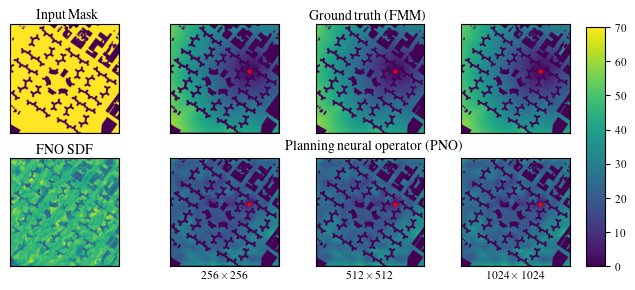

In [27]:
trainDataCity1024, testDataCity1024 = load_dataset("cityData/1024x1024", trainDataCount=0, testDataCount=1, batch_size=batch_size)
trainDataCity512, testDataCity512 = load_dataset("cityData/512x512", trainDataCount=0, testDataCount=1, batch_size=batch_size)
trainDataCity256, testDataCity256 = load_dataset("cityData/256x256", trainDataCount=0, testDataCount=1, batch_size=batch_size)

plot_paper_fig(testDataCity256, testDataCity512 , testDataCity1024,modelPNOwPINN, modelSDF,mask_func_arr[3], 0, "superResExampleNYC.pdf")

### Figure 7

In [28]:
def plot_example(model, modelPINN, modelSDF, mask_func, data, example_num, filename, normalizer=None):
    set_ticks = True
    height_add = set_size(469, 0.99, (2, 3))[1]
    fig = plt.figure(figsize= set_size(469, 0.99, (2, 3),  height_add=height_add))
    subfigs = fig.subfigures(nrows=1, ncols=1, hspace=0)
    gs1 = subfigs.add_gridspec(2, 6, height_ratios=[1, 1])
    ax1a = subfigs.add_subplot(gs1[0, 0:2])
    ax2a = subfigs.add_subplot(gs1[0, 2:4])
    ax3a = subfigs.add_subplot(gs1[0, 4:6])
    ax4a = subfigs.add_subplot(gs1[1, 0:3])
    ax1 = subfigs.add_subplot(gs1[1, 3:6])

    axes1 = [ax1a, ax2a, ax3a, ax4a, ax1]
    subfigs.suptitle("Value functions and relative error between FMM (Unseen)", fontsize="x-large")

    # Get vmin, vmax
    vmin_top = np.inf
    vmax_top = -np.inf
    vmin_bottom = 0
    vmax_bottom = -np.inf
    loss_func = LpLoss(d=2, p=2)
    set_ticks = False
    vmin_top = 0
    vmax_top = 55
    # PLOT PINN model
    with torch.no_grad():
        for idx, (mask, chi,goals, y) in enumerate(data):
            chi = smooth_chi(mask, modelSDF(mask), 5)    
            out = modelPINN(chi, goals)
            if normalizer is not None:
                out = normalizer.decode(out) * mask_func(mask)
            else:
                out = out*mask    
            if idx == 1:
                break
        axes1[1].imshow(out[example_num].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
        axes1[1].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro')
        axes1[1].contour(out[example_num].reshape(out.shape[1], out.shape[2]).detach().cpu().numpy(),levels=30, colors="k",linewidths=0.3)
        im2 = axes1[4].imshow(torch.abs(out[example_num]-y[example_num]).detach().cpu().numpy(), vmin=0, vmax=5, origin="lower")

        axes1[1].set_title("PNO w/ PINN")
        axes1[4].set_title("PNO w/ \nPINN error")

        if set_ticks:
            axes1[1].set_xticks([0, 250, 500, 750, 1000])
            axes1[1].set_yticks([0, 250, 500, 750, 1000])

    # PLOT without PINN
    with torch.no_grad():
        for idx, (mask, chi,goals, y) in enumerate(data):
            chi = smooth_chi(mask, modelSDF(mask), 5)    
            out = model(chi, goals)
            if normalizer is not None:
                out = normalizer.decode(out) * mask_func(mask)
            else:
                out = out*mask    
            if idx == 1:
                break
    axes1[0].imshow(out[example_num].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
    axes1[0].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro')
    axes1[0].contour(out[example_num].reshape(out.shape[1], out.shape[2]).detach().cpu().numpy(),levels=30, colors="k",linewidths=0.3)
    axes1[0].set_title("PNO w/out PINN")

    # FMM EXAMPLE
    axes1[3].imshow(torch.abs(out[example_num]-y[example_num]).detach().cpu().numpy(), vmin=0, vmax=5, origin="lower")
    axes1[3].set_title("Error PNO \n w/out PINN ")
    if set_ticks:
        axes1[0].set_xticks([0, 250, 500, 750, 1000])
        axes1[0].set_yticks([0, 250, 500, 750, 1000])

    axes1[2].set_xticks([])  
    axes1[2].set_yticks([])    
    axes1[1].set_xticks([])  
    axes1[1].set_yticks([]) 
    axes1[0].set_xticks([])  
    axes1[0].set_yticks([])
    axes1[3].set_xticks([])  
    axes1[3].set_yticks([])
    axes1[4].set_xticks([])  
    axes1[4].set_yticks([])  
        
    y = y[example_num].detach().cpu().numpy()
    im = axes1[2].imshow(y,  cmap='viridis', vmin=vmin_top, vmax=vmax_top, origin="lower")
    axes1[2].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro')
    axes1[2].contour(y[:, :, 0],levels=20, colors="k",linewidths=0.3)

    axes1[2].set_title("FMM")
    cb_ax = subfigs.add_axes([.91,.56,.02,.29])
    fig.colorbar(im, orientation='vertical',cax=cb_ax)
    #subfigs.subplots_adjust(left=0.05, bottom=0.03, right=.9, top=0.92, hspace=.32, wspace=0.5)

    cb_ax = subfigs.add_axes([.87,.11,.02,.35])
    fig.colorbar(im2, orientation='vertical',cax=cb_ax)
    plt.savefig(filename, dpi=300)
    plt.show()
    #subfigs.subplots_adjust(left=0.05, bottom=0.1, right=.9, top=0.85, hspace=.4, wspace=0.3)

def plot_example_grad(model, modelPINN, modelSDF, mask_func, data, example_num, filename, normalizer=None):
    set_ticks = True
    height_add = set_size(469, 0.99, (2, 3))[1]
    fig = plt.figure(figsize= set_size(469, 0.99, (2, 3),  height_add=height_add))
    subfigs = fig.subfigures(nrows=1, ncols=1, hspace=0)
    gs1 = subfigs.add_gridspec(2, 6)
    ax1a = subfigs.add_subplot(gs1[0, 0:2])
    ax2a = subfigs.add_subplot(gs1[0, 2:4])
    ax5a = subfigs.add_subplot(gs1[0, 4:6])

    ax3a = subfigs.add_subplot(gs1[1, 0:3])
    ax4a = subfigs.add_subplot(gs1[1, 3:6])

    axes1 = [ax1a, ax2a, ax3a, ax4a, ax5a]
    subfigs.suptitle(r"Gradient of value function ($\|\nabla V(x)\|$) and error \\ of gradient value function ($|\|\nabla V(x)\|-c(x)|$) (Seen)", fontsize="x-large")

    # Get vmin, vmax
    vmin_top = np.inf
    vmax_top = -np.inf
    vmin_bottom = 0
    vmax_bottom = -np.inf
    loss_func = LpLoss(d=2, p=2)
    set_ticks = False
    vmin_top = 0
    vmax_top = 2
    # PLOT PINN MODEL
    with torch.no_grad():
        for idx, (mask, chi,goals, y) in enumerate(data):
            chi = smooth_chi(mask, modelSDF(mask), 5)    
            out = modelPINN(chi, goals)
            if normalizer is not None:
                out = normalizer.decode(out) * mask_func(mask)
            else:
                out = out*mask    
            if idx == 1:
                break
    grad_out = torch.linalg.vector_norm(torch.stack(list(torch.gradient(out[example_num].reshape(1, out.shape[1], out.shape[2]), dim=[1, 2])), dim=0), dim=0)
    grad_y = torch.linalg.vector_norm(torch.stack(list(torch.gradient(y[example_num].reshape(1, y.shape[1], y.shape[2]), dim=[1, 2])), dim=0), dim=0)
    im= axes1[1].imshow(grad_out[0].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
    axes1[1].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro')

    axes1[1].set_title("PNO w/ PINN")
    
    if set_ticks:
        axes1[1].set_xticks([0, 250, 500, 750, 1000])
        axes1[1].set_yticks([0, 250, 500, 750, 1000])

    imOMEGA = axes1[3].imshow(torch.abs(grad_out[0]-grad_y[0]).detach().cpu().numpy(), vmin=0, vmax=1.5, origin="lower")
    axes1[3].set_title("PNO w PINN\n Gradient Error")
   
    with torch.no_grad():
        for idx, (mask, chi,goals, y) in enumerate(data):
            chi = smooth_chi(mask, modelSDF(mask), 5)    
            out = model(chi, goals)
            if normalizer is not None:
                out = normalizer.decode(out) * mask_func(mask)
            else:
                out = out*mask    
            if idx == 1:
                break

    grad_out = torch.linalg.vector_norm(torch.stack(list(torch.gradient(out[example_num].reshape(1, out.shape[1], out.shape[2]), dim=[1, 2])), dim=0), dim=0)
    grad_y = torch.linalg.vector_norm(torch.stack(list(torch.gradient(y[example_num].reshape(1, y.shape[1], y.shape[2]), dim=[1, 2])), dim=0), dim=0)
    
    axes1[4].imshow(grad_y[0].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
    axes1[4].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro')
    axes1[4].set_title("FMM")
    axes1[0].set_title("PNO w/out PINN")
    print(loss_func(grad_out.view(1, y.shape[1], y.shape[2]), grad_y.view(1, y.shape[1], y.shape[2])))
    axes1[0].imshow(grad_out[0].detach().cpu().numpy(), vmin=vmin_top, vmax=vmax_top, origin="lower")
    axes1[0].plot(goals[example_num][0].detach().cpu().numpy(), goals[example_num][1].detach().cpu().numpy(), 'ro')
    if set_ticks:
        axes1[0].set_xticks([0, 250, 500, 750, 1000])
        axes1[0].set_yticks([0, 250, 500, 750, 1000])
    axes1[2].imshow(torch.abs(grad_out[0]-grad_y[0]).detach().cpu().numpy(), vmin=0, vmax=1.5, origin="lower")
    axes1[2].set_title("PNO w/out PINN\n Gradient Error")
    axes1[2].set_xticks([])  
    axes1[2].set_yticks([])    
    axes1[1].set_xticks([])  
    axes1[1].set_yticks([]) 
    axes1[0].set_xticks([])  
    axes1[0].set_yticks([])
    axes1[3].set_xticks([])  
    axes1[3].set_yticks([])  
    axes1[4].set_xticks([])  
    axes1[4].set_yticks([])

    cb_ax = subfigs.add_axes([.91,.54,.02,.33])
    fig.colorbar(im, orientation='vertical',cax=cb_ax)
    #subfigs.subplots_adjust(left=0.05, bottom=0.0, right=.9, top=1, hspace=-0.3, wspace=0.5)

    cb_ax = subfigs.add_axes([.91,.13,.02,.33])
    fig.colorbar(imOMEGA, orientation='vertical',cax=cb_ax)
    plt.savefig(filename, dpi=300)
    plt.show()
    #subfigs.subplots_adjust(left=0.05, bottom=0.1, right=.9, top=0.85, hspace=.4, wspace=0.3)

Load dataset complete(train size, test size) 800 200


/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 65, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 65, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reus

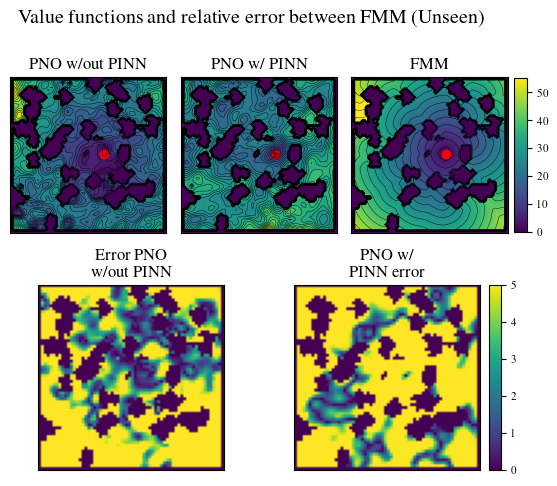

/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 65, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/Resize.cpp:38.)
  return func(*args, **kwargs)
/Users/tree/miniconda3/envs/pno/lib/python3.10/site-packages/torch/utils/_device.py:109: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 16, 65, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reus

tensor(0.3164, device='mps:0')


python(89722) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89723) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89724) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89725) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89726) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89727) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89728) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89729) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89730) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89731) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89732) Malloc

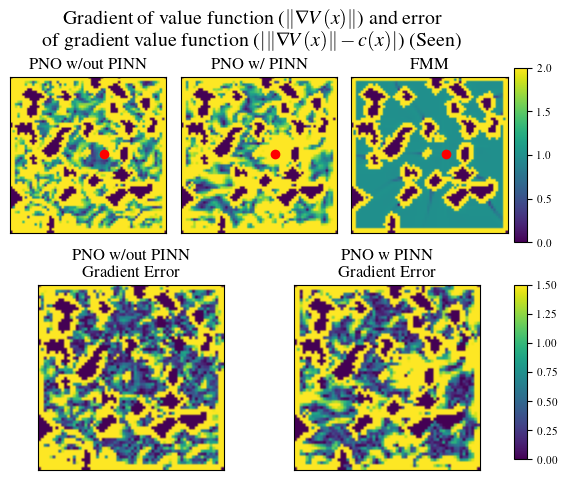

In [29]:
trainData64, testData64 = load_dataset("synthetic/64x64", trainDataCount=0.8, testDataCount=0.2, batch_size=20)

# We plot an example with a goal in the center for clarity - but one can visualize many different examples by changing the number 2 to 
# any number between [0, batch_size). 
plot_example(modelPNO, modelPNOwPINN, modelSDF, mask_func_arr[2], testData64, 2, "pinnOUTDIST2.pdf")
plot_example_grad(modelPNO, modelPNOwPINN, modelSDF, mask_func_arr[2], testData64, 2, "pinnGradOUTDIST2.pdf")